<a href="https://colab.research.google.com/github/alexsandoval05/Revenue-sustainability-Chrysal/blob/main/chrysal_profit_sustainability.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#  **Análisis de utilidades de implementación de proyectos de sostenibilidad en Chrysal**
OBJETIVO: Definir rentabilidad anual en la implementación de proyectos de sostenibilidad y revisar si la inversion esta generando mayores ingresos.

## 1. 🧩 **Cargar y Explorar - Visión General**

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

sales = pd.read_csv("/content/Tabla1_Chrysal_Sustainability.csv")
marketing = pd.read_csv("/content/Tabla2_Marketing_Campaign.csv")
costs = pd.read_csv("/content/Tabla3_Costs.csv")

In [ ]:
sales_clean = sales.copy()
marketing_clean = marketing.copy()
costs_clean = costs.copy()

In [ ]:
sales_clean.head()

,sales_order_number,date,country,product_reference,campaign_id,category_product,sales_revenue_usd,production_cost_usd,customer_id
0,SO-000001,2024-02-01,Holanda,Chrysal Grow X,4,Fungicida,127316.56,173574.63,1
1,SO-000002,2025-01-01,Kenya,Chrysal Flora F,3,Nutricional,28100.09,18200.66,2
2,SO-000003,2022-05-01,Ecuador,Chrysal Flora F,4,Insecticida,222096.76,101783.75,3
3,SO-000004,2024-05-01,Kenya,Chrysal Flora F,3,Nutricional,114488.78,73680.46,4
4,SO-000005,2024-04-01,Colombia,Chrysal Grow X,2,Insecticida,140394.64,78617.18,5


In [ ]:
sales_clean["Date"] = pd.to_datetime(sales_clean["date"], errors="coerce", utc=True)
sales_clean["Year"]  = sales_clean["Date"].dt.year
sales_clean["Month"] = sales_clean["Date"].dt.month
sales_clean.head()

,sales_order_number,date,country,product_reference,campaign_id,category_product,sales_revenue_usd,production_cost_usd,customer_id,Date,Year,Month
0,SO-000001,2024-02-01,Holanda,Chrysal Grow X,4,Fungicida,127316.56,173574.63,1,2024-02-01 00:00:00+00:00,2024,2
1,SO-000002,2025-01-01,Kenya,Chrysal Flora F,3,Nutricional,28100.09,18200.66,2,2025-01-01 00:00:00+00:00,2025,1
2,SO-000003,2022-05-01,Ecuador,Chrysal Flora F,4,Insecticida,222096.76,101783.75,3,2022-05-01 00:00:00+00:00,2022,5
3,SO-000004,2024-05-01,Kenya,Chrysal Flora F,3,Nutricional,114488.78,73680.46,4,2024-05-01 00:00:00+00:00,2024,5
4,SO-000005,2024-04-01,Colombia,Chrysal Grow X,2,Insecticida,140394.64,78617.18,5,2024-04-01 00:00:00+00:00,2024,4


In [ ]:
sales_clean.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 715 entries, 0 to 714
Data columns (total 12 columns):
 #   Column               Non-Null Count  Dtype              
---  ------               --------------  -----              
 0   sales_order_number   715 non-null    object             
 1   date                 715 non-null    object             
 2   country              715 non-null    object             
 3   product_reference    715 non-null    object             
 4   campaign_id          715 non-null    int64              
 5   category_product     715 non-null    object             
 6   sales_revenue_usd    645 non-null    float64            
 7   production_cost_usd  715 non-null    float64            
 8   customer_id          715 non-null    int64              
 9   Date                 715 non-null    datetime64[ns, UTC]
 10  Year                 715 non-null    int32              
 11  Month                715 non-null    int32              
dtypes: datetime64[ns, UTC]

In [ ]:
sales_clean.nunique()

,0
sales_order_number,700
date,20
country,4
product_reference,5
campaign_id,4
category_product,5
sales_revenue_usd,645
production_cost_usd,700
customer_id,700
Date,20


In [ ]:
marketing_clean.head()

,Marketing_cost,Campaign_ID,Marketing_campaign_type
0,11000.0,4,Social Media
1,3000.0,3,Influencers Agro
2,11000.0,4,Social Media
3,3000.0,3,Influencers Agro
4,60000.0,2,Field Campaign


In [ ]:
marketing_clean["Marketing_campaign_type"].value_counts()

,count
Marketing_campaign_type,
Social Media,2
Influencers Agro,2
Field Campaign,2
Email Marketing,2


In [ ]:
marketing_clean.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8 entries, 0 to 7
Data columns (total 3 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   Marketing_cost           8 non-null      float64
 1   Campaign_ID              8 non-null      int64  
 2   Marketing_campaign_type  8 non-null      object 
dtypes: float64(1), int64(1), object(1)
memory usage: 324.0+ bytes


In [ ]:
costs_clean.head()

,Sales_order_number,Product_reference,Waste_kg,Disposal_waste_cost
0,SO-000001,Chrysal Grow X,750.32,375.160
1,SO-000002,Chrysal Flora F,209.94,104.970
2,SO-000003,Chrysal Flora F,882.49,441.245
3,SO-000004,Chrysal Flora F,982.56,491.280
4,SO-000005,Chrysal Grow X,582.48,291.240


In [ ]:
costs_clean.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 700 entries, 0 to 699
Data columns (total 4 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   Sales_order_number   700 non-null    object 
 1   Product_reference    700 non-null    object 
 2   Waste_kg             665 non-null    float64
 3   Disposal_waste_cost  665 non-null    float64
dtypes: float64(2), object(2)
memory usage: 22.0+ KB


In [ ]:
costs_clean.nunique()

,0
Sales_order_number,700
Product_reference,5
Waste_kg,664
Disposal_waste_cost,664


## **1.2 🧩 Identificación de problemas de calidad de datos**
Calcule la cantidad de vacios en "sales" y "costs"

In [ ]:
sales_clean.isna().sum()
print('Porcentaje de nulos',sales_clean.isna().sum())
print('Porcentaje de nulos',sales_clean.isna().mean())

Porcentaje de nulos sales_order_number      0
date                    0
country                 0
product_reference       0
campaign_id             0
category_product        0
sales_revenue_usd      70
production_cost_usd     0
customer_id             0
Date                    0
Year                    0
Month                   0
dtype: int64
Porcentaje de nulos sales_order_number     0.000000
date                   0.000000
country                0.000000
product_reference      0.000000
campaign_id            0.000000
category_product       0.000000
sales_revenue_usd      0.097902
production_cost_usd    0.000000
customer_id            0.000000
Date                   0.000000
Year                   0.000000
Month                  0.000000
dtype: float64


In [ ]:
costs_clean.isna().sum()
print('Porcentaje de nulos',costs_clean.isna().sum())
print('Porcentaje de nulos',costs_clean.isna().mean())


Porcentaje de nulos Sales_order_number      0
Product_reference       0
Waste_kg               35
Disposal_waste_cost    35
dtype: int64
Porcentaje de nulos Sales_order_number     0.00
Product_reference      0.00
Waste_kg               0.05
Disposal_waste_cost    0.05
dtype: float64


In [ ]:
costs_clean.nunique()

,0
Sales_order_number,700
Product_reference,5
Waste_kg,664
Disposal_waste_cost,664


##**CONCLUSION**
1.1- Se evidencio 10% de datos vacios en "sales_revenue_USD" por tal razon es importante averiguar a que segmento se deben estos vacios para entender si es un faltante al azar o no.


In [ ]:
sales_clean['sales_revenue_usd'].isna().groupby(sales_clean['country']).sum().sort_values(ascending=False)

,sales_revenue_usd
country,
Colombia,28
Holanda,16
Ecuador,13
Kenya,13


1.2- En la tabla anterior se observa que Colombia tiene 28 datos vacios de 70 que es aprox el 40 % de los datos. Por tal razon no son faltantes al azar sino que algo ocurrio en Colombia que no tiene la informacion completa.

# **2- Estadistica Descriptiva**

In [ ]:
print("sales",sales_clean.describe())
print("marketing",marketing_clean.describe())
print("costs",costs_clean.describe())

sales        campaign_id  sales_revenue_usd  production_cost_usd  customer_id  \
count   715.000000         645.000000           715.000000   715.000000   
mean      2.567832       99331.046663         78845.210490   343.167832   
std       1.138491       59265.002902         67240.539082   206.264257   
min       1.000000        4838.780000          2585.940000     1.000000   
25%       2.000000       54249.510000         32732.395000   164.500000   
50%       3.000000       98087.270000         62004.920000   343.000000   
75%       4.000000      137371.560000         95090.645000   521.500000   
max       4.000000      318415.266281        400616.430000   700.000000   

              Year       Month  
count   715.000000  715.000000  
mean   2023.569231    2.976224  
std       1.126037    1.439049  
min    2022.000000    1.000000  
25%    2023.000000    2.000000  
50%    2024.000000    3.000000  
75%    2025.000000    4.000000  
max    2025.000000    5.000000  
marketing        Mark

**HALLAZGOS:**
- **Sales Revenue USD**: posiblemente tiene un sesgo a la derecha "outlier" ya que el "max" es el doble del "75%"
- **Production_cost**: Es posible sistribucion normal pero se debe descartar con histograma
- **Waste_kg** y **Disposal_waste_cost**: Posible distribucion con sesgos o "outlier"a la izquierda ya que el min es 10 veces menor que el "25%"

## **2.1 Analisis complementario**
### **2.1.1 Realice pruebas de comparacion de media y mediana** para entender la tendencia de "Sales_revenue_USD" y "production_costs" en tabla de "sales_clean"

In [ ]:
columnas_numericas_sales = sales_clean[['sales_revenue_usd', 'production_cost_usd']]

for col in columnas_numericas_sales:
    # Media y mediana de cada columna
    print(col)
    print("Promedio", columnas_numericas_sales[col].mean(),"- Mediana:", columnas_numericas_sales[col].median())
    print()

sales_revenue_usd
Promedio 99331.04666316079 - Mediana: 98087.27

production_cost_usd
Promedio 78845.21048951049 - Mediana: 62004.92



## **CONCLUSIONES:**

- Se evidencia ligera tendencia de sesgo a la derecha para "Sales_revenue_USD" por tal razon los datos vacios se reemplazaran por la mediana.
- En "production_cost_usd" si se evidencia diferencia sifnificativa entre mediana y promedio.



### 2.1.3 Realice evaluacion **agrupando por año y pais** para revisar dominancia en la columna "Sales_revenue_USD"

In [ ]:
resumen_pais = (
    sales_clean
    .groupby(['country'])
    .agg(
        avg_sales=('sales_revenue_usd', 'mean'),
        count_sales=('sales_revenue_usd', 'count'),
        desv_sales=('sales_revenue_usd', 'std'),
        min_sales=('sales_revenue_usd', 'min'),
        max_sales=('sales_revenue_usd', 'max'),

    )
    .reset_index()
)
resumen_pais

,country,avg_sales,count_sales,desv_sales,min_sales,max_sales
0,Colombia,96923.429463,149,53941.297638,6342.83,195064.000000
1,Ecuador,93790.497600,175,52405.155518,5427.42,222096.760000
2,Holanda,110891.478838,174,74861.689611,4838.78,318415.266281
3,Kenya,94683.535442,147,49049.654839,5356.74,199479.560000


**CONCLUSIONES**:

No se evidencia dominancia de tendencia por año y pais.

In [ ]:
columnas_categoricas_1 = sales_clean[['country','product_reference','category_product']]
columnas_categoricas_2 = marketing_clean[['Marketing_campaign_type']]

print(columnas_categoricas_1.describe())
print(columnas_categoricas_2.describe())


        country product_reference category_product
count       715               715              715
unique        4                 5                5
top     Holanda    Chrysal Grow X      Nutricional
freq        190               154              157
       Marketing_campaign_type
count                        8
unique                       4
top               Social Media
freq                         2


In [ ]:
for col in columnas_categoricas_1:
    print(col)
    print(sales_clean[col].value_counts())
    print()

country
country
Holanda     190
Ecuador     188
Colombia    177
Kenya       160
Name: count, dtype: int64

product_reference
product_reference
Chrysal Grow X       154
Chrysal Flora F      154
Chrysal Root R       149
Chrysal Protect Y    148
Chrysal Boost Z      110
Name: count, dtype: int64

category_product
category_product
Nutricional                 157
Fertilizante                145
Fungicida                   140
Insecticida                 140
Regulador de crecimiento    133
Name: count, dtype: int64



In [ ]:
print(marketing_clean["Marketing_campaign_type"].value_counts())

Marketing_campaign_type
Social Media        2
Influencers Agro    2
Field Campaign      2
Email Marketing     2
Name: count, dtype: int64


**CONCLUSION DE ANALISIS:**




De acuerdo a este conteo de columnas **categoricas dominantes**  **NO** se evidencia una afectacion especifica por alguna categoria evaluada.

## **3- Visualizacion Diagnóstica**

In [ ]:
sales_paises = sales_clean[(sales_clean['country']=='Colombia') |
                  (sales_clean['country']=='Holanda') |
                  (sales_clean['country']=='Kenya') |
                  (sales_clean['country']=='Ecuador')
]
sales_paises

,sales_order_number,date,country,product_reference,campaign_id,category_product,sales_revenue_usd,production_cost_usd,customer_id,Date,Year,Month
0,SO-000001,2024-02-01,Holanda,Chrysal Grow X,4,Fungicida,127316.560000,173574.63,1,2024-02-01 00:00:00+00:00,2024,2
1,SO-000002,2025-01-01,Kenya,Chrysal Flora F,3,Nutricional,28100.090000,18200.66,2,2025-01-01 00:00:00+00:00,2025,1
2,SO-000003,2022-05-01,Ecuador,Chrysal Flora F,4,Insecticida,222096.760000,101783.75,3,2022-05-01 00:00:00+00:00,2022,5
3,SO-000004,2024-05-01,Kenya,Chrysal Flora F,3,Nutricional,114488.780000,73680.46,4,2024-05-01 00:00:00+00:00,2024,5
4,SO-000005,2024-04-01,Colombia,Chrysal Grow X,2,Insecticida,140394.640000,78617.18,5,2024-04-01 00:00:00+00:00,2024,4
...,...,...,...,...,...,...,...,...,...,...,...,...
710,SO-000001,2024-02-01,Holanda,Chrysal Grow X,4,Fungicida,289268.794729,173574.63,1,2024-02-01 00:00:00+00:00,2024,2
711,SO-000001,2024-02-01,Holanda,Chrysal Grow X,4,Fungicida,298272.958236,173574.63,1,2024-02-01 00:00:00+00:00,2024,2
712,SO-000001,2024-02-01,Holanda,Chrysal Grow X,4,Fungicida,300072.327896,173574.63,1,2024-02-01 00:00:00+00:00,2024,2
713,SO-000001,2024-02-01,Holanda,Chrysal Grow X,4,Fungicida,317866.976951,173574.63,1,2024-02-01 00:00:00+00:00,2024,2


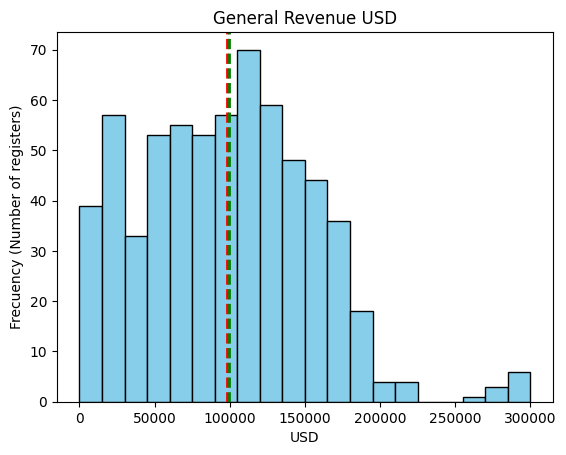

In [ ]:
plt.hist(sales_clean['sales_revenue_usd'], bins=20, color='skyblue', edgecolor='black', range=(0,300000)) # figsize=(ancho, alto)
median_sales = sales_clean['sales_revenue_usd'].median()
average_sales = sales_clean['sales_revenue_usd'].mean()

plt.axvline(median_sales, color='red', linestyle='dashed', linewidth=2, label='Media')
plt.axvline(average_sales, color='green', linestyle='dashed', linewidth=2, label='Mediana')

plt.title('General Revenue USD')
plt.xlabel('USD')
plt.ylabel('Frecuency (Number of registers)')
plt.show()

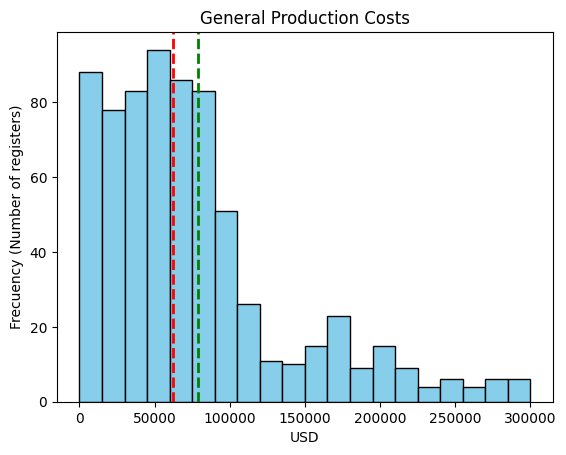

In [ ]:
plt.hist(sales_clean['production_cost_usd'], bins=20, color='skyblue', edgecolor='black', range=(0,300000)) # figsize=(ancho, alto)
median_sales = sales_clean['production_cost_usd'].median()
average_sales = sales_clean['production_cost_usd'].mean()

plt.axvline(median_sales, color='red', linestyle='dashed', linewidth=2, label='Media')
plt.axvline(average_sales, color='green', linestyle='dashed', linewidth=2, label='Mediana')

plt.title('General Production Costs')
plt.xlabel('USD')
plt.ylabel('Frecuency (Number of registers)')
plt.show()

##4- Identificacion formal de Outliers
- Se realizara prueba de IQR Indice Intercuartil para entender el comportamiento de los outliers.

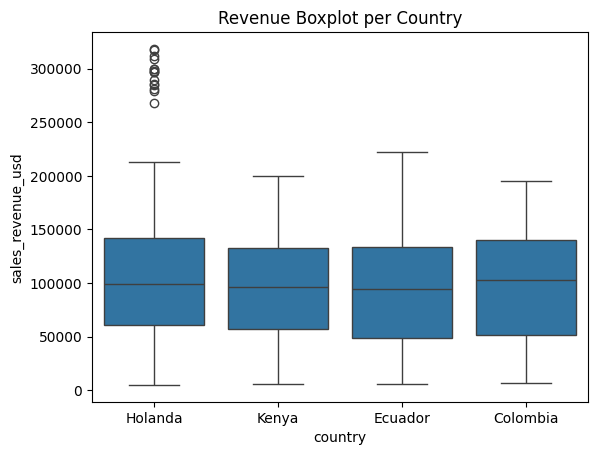

In [ ]:
sns.boxplot(data=sales_paises, x="country", y="sales_revenue_usd")
plt.title(f'Revenue Boxplot per Country')
plt.show()


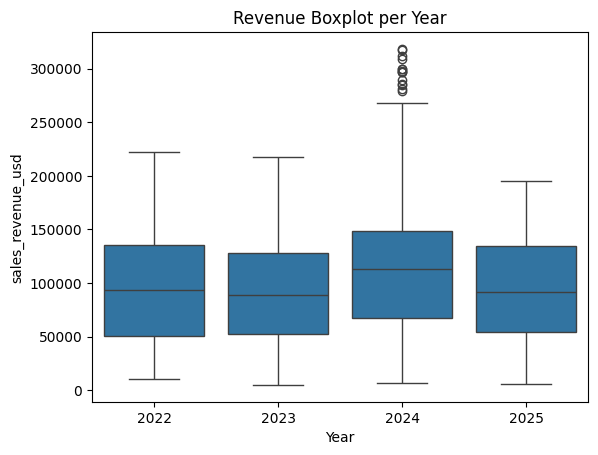

In [ ]:
sns.boxplot(data=sales_paises, x="Year", y="sales_revenue_usd")
plt.title(f'Revenue Boxplot per Year')
plt.show()


##5 - Limpieza automatica por pipeline:

**- Teniendo en cuenta que los promedios y medianas de "sales_revenue_usd" por paises son similares entre si se reemplazara por la mediana para completar los valores vacios.

In [ ]:
sales_clean['sales_revenue_usd'] = sales_clean['sales_revenue_usd'].fillna(sales_clean['sales_revenue_usd'].median())
print('Porcentaje de nulos',sales_clean.isna().sum())

Porcentaje de nulos sales_order_number     0
date                   0
country                0
product_reference      0
campaign_id            0
category_product       0
sales_revenue_usd      0
production_cost_usd    0
customer_id            0
Date                   0
Year                   0
Month                  0
dtype: int64


##7- Unificación tabla de interes para calculos de **% Profit y % ROI**.

**- Agregue a la tabla de "Sales_clean" la tabla de "Costs"**

In [ ]:
costs.rename(columns={'Sales_order_number': 'sales_order_number'}, inplace=True)
costs_clean = costs.copy()

sales_clean_small = sales_clean[['sales_order_number','sales_revenue_usd','Year','production_cost_usd','country','product_reference']]

sales_final = pd.merge(sales_clean_small, costs_clean, on=['sales_order_number'], how='left')

sales_final.head()

,sales_order_number,sales_revenue_usd,Year,production_cost_usd,country,product_reference,Product_reference,Waste_kg,Disposal_waste_cost
0,SO-000001,127316.56,2024,173574.63,Holanda,Chrysal Grow X,Chrysal Grow X,750.32,375.160
1,SO-000002,28100.09,2025,18200.66,Kenya,Chrysal Flora F,Chrysal Flora F,209.94,104.970
2,SO-000003,222096.76,2022,101783.75,Ecuador,Chrysal Flora F,Chrysal Flora F,882.49,441.245
3,SO-000004,114488.78,2024,73680.46,Kenya,Chrysal Flora F,Chrysal Flora F,982.56,491.280
4,SO-000005,140394.64,2024,78617.18,Colombia,Chrysal Grow X,Chrysal Grow X,582.48,291.240


In [ ]:
sales_final.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 715 entries, 0 to 714
Data columns (total 9 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   sales_order_number   715 non-null    object 
 1   sales_revenue_usd    715 non-null    float64
 2   Year                 715 non-null    int32  
 3   production_cost_usd  715 non-null    float64
 4   country              715 non-null    object 
 5   product_reference    715 non-null    object 
 6   Product_reference    715 non-null    object 
 7   Waste_kg             680 non-null    float64
 8   Disposal_waste_cost  680 non-null    float64
dtypes: float64(4), int32(1), object(4)
memory usage: 47.6+ KB


#**Aplica las siguientes formulas para calculo de "gross_profit" :**

- Costo total = Production_costs + Disposal_waste_cost
- Gross profit = Sales_revenus - costo_total
- % profit-margin = ( gross_profit / Sales_revenue_usd ) * 100

In [ ]:
sales_final['costo_total'] = sales_final['production_cost_usd'] + sales_final['Disposal_waste_cost']
sales_final['gross_profit'] = sales_final['sales_revenue_usd'] - sales_final['costo_total']
sales_final['margin_pct'] = (sales_final['gross_profit']) *100 / sales_final['sales_revenue_usd']
sales_final

,sales_order_number,sales_revenue_usd,Year,production_cost_usd,country,product_reference,Product_reference,Waste_kg,Disposal_waste_cost,costo_total,gross_profit,margin_pct
0,SO-000001,127316.560000,2024,173574.63,Holanda,Chrysal Grow X,Chrysal Grow X,750.32,375.160,173949.790,-46633.230000,-36.627780
1,SO-000002,28100.090000,2025,18200.66,Kenya,Chrysal Flora F,Chrysal Flora F,209.94,104.970,18305.630,9794.460000,34.855618
2,SO-000003,222096.760000,2022,101783.75,Ecuador,Chrysal Flora F,Chrysal Flora F,882.49,441.245,102224.995,119871.765000,53.972766
3,SO-000004,114488.780000,2024,73680.46,Kenya,Chrysal Flora F,Chrysal Flora F,982.56,491.280,74171.740,40317.040000,35.214839
4,SO-000005,140394.640000,2024,78617.18,Colombia,Chrysal Grow X,Chrysal Grow X,582.48,291.240,78908.420,61486.220000,43.795276
...,...,...,...,...,...,...,...,...,...,...,...,...
710,SO-000001,289268.794729,2024,173574.63,Holanda,Chrysal Grow X,Chrysal Grow X,750.32,375.160,173949.790,115319.004729,39.865691
711,SO-000001,298272.958236,2024,173574.63,Holanda,Chrysal Grow X,Chrysal Grow X,750.32,375.160,173949.790,124323.168236,41.681006
712,SO-000001,300072.327896,2024,173574.63,Holanda,Chrysal Grow X,Chrysal Grow X,750.32,375.160,173949.790,126122.537896,42.030713
713,SO-000001,317866.976951,2024,173574.63,Holanda,Chrysal Grow X,Chrysal Grow X,750.32,375.160,173949.790,143917.186951,45.275916


In [ ]:
profit_percent_year = (
    sales_final
    .groupby(['Year'])
    .agg(
        avg_profit_pct=('margin_pct', 'mean'),
        gross_profit_USD=('margin_pct', 'sum'),
    )
    .reset_index()
)
profit_percent_year

,Year,avg_profit_pct,gross_profit_USD
0,2022,17.091546,2700.464218
1,2023,21.128433,3465.063005
2,2024,18.500754,3182.129741
3,2025,12.384654,2303.545633


In [ ]:
profit_percent_country = (
    sales_final
    .groupby(['country'])
    .agg(
        avg_profit_pct=('margin_pct', 'mean'),
        gross_profit_USD=('margin_pct', 'sum'),
    )
    .reset_index()
)
profit_percent_country

,country,avg_profit_pct,gross_profit_USD
0,Colombia,45.637520,7393.278251
1,Ecuador,45.136693,8034.331282
2,Holanda,-58.095981,-10747.756571
3,Kenya,44.976449,6971.349633


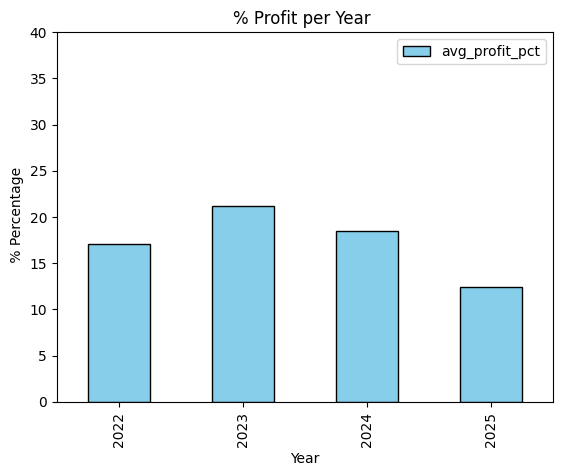

In [ ]:
profit_percent_year.plot(x='Year', y=['avg_profit_pct'], kind='bar', color='skyblue', edgecolor='black')
plt.xticks(rotation=90)
plt.title('% Profit per Year ')
plt.ylabel(' % Percentage')
plt.ylim(0,40)
plt.show()

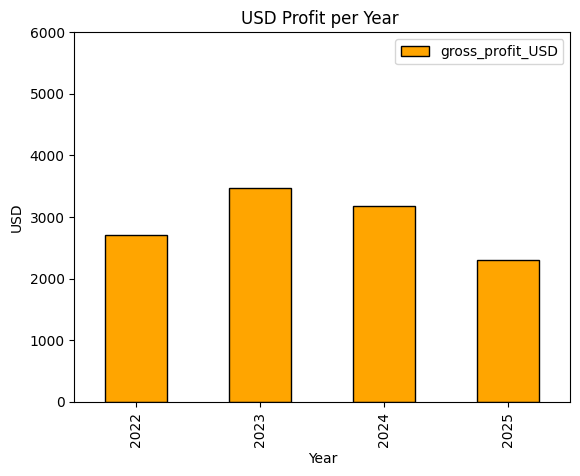

In [ ]:
profit_percent_year.plot(x='Year', y=['gross_profit_USD'], kind='bar', color='orange', edgecolor='black')
plt.xticks(rotation=90)
plt.title('USD Profit per Year ')
plt.ylabel('USD')
plt.ylim(0,6000)
plt.show()

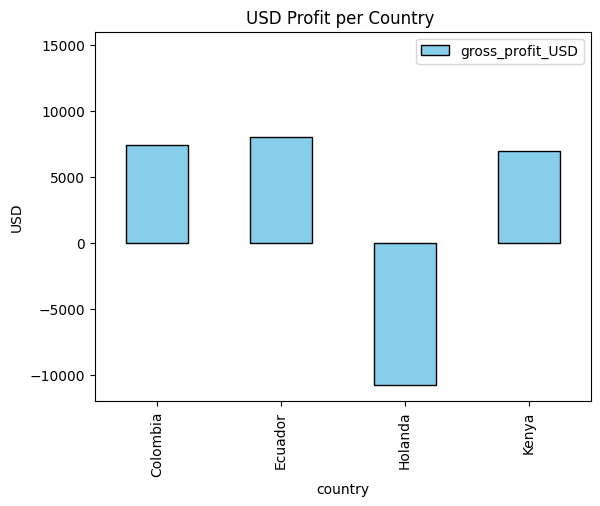

In [ ]:
profit_percent_country.plot(x='country', y=['gross_profit_USD'], kind='bar', color='skyblue', edgecolor='black')
plt.xticks(rotation=90)
plt.title('USD Profit per Country ')
plt.ylabel('USD')
plt.ylim(-12000,16000)
plt.show()

**🧩CONCLUSIONES:**
- Se evidencia que Holanda ha tenido **perdidas por cuantia de -U$10.000** con respecto a **utilidades de USD 7.000 que han presentado cada una de las otras sedes** como Colombia, Ecuador y Kenya posiblmente por altos costos operacionales de Holanda y nuevas tendencias del mercado floricultor.
- A nivel global las utilidades de toda la compañia fueron del 21% en 2023 y ha tenido una tendencia ha disminuir en el 2024 y 2025 con utilidadesdes del 16  y 12 % respectivamente.

In [ ]:
sales_final.head()

,sales_order_number,sales_revenue_usd,Year,production_cost_usd,country,product_reference,Product_reference,Waste_kg,Disposal_waste_cost,costo_total,gross_profit,margin_pct
0,SO-000001,127316.56,2024,173574.63,Holanda,Chrysal Grow X,Chrysal Grow X,750.32,375.160,173949.790,-46633.230,-36.627780
1,SO-000002,28100.09,2025,18200.66,Kenya,Chrysal Flora F,Chrysal Flora F,209.94,104.970,18305.630,9794.460,34.855618
2,SO-000003,222096.76,2022,101783.75,Ecuador,Chrysal Flora F,Chrysal Flora F,882.49,441.245,102224.995,119871.765,53.972766
3,SO-000004,114488.78,2024,73680.46,Kenya,Chrysal Flora F,Chrysal Flora F,982.56,491.280,74171.740,40317.040,35.214839
4,SO-000005,140394.64,2024,78617.18,Colombia,Chrysal Grow X,Chrysal Grow X,582.48,291.240,78908.420,61486.220,43.795276


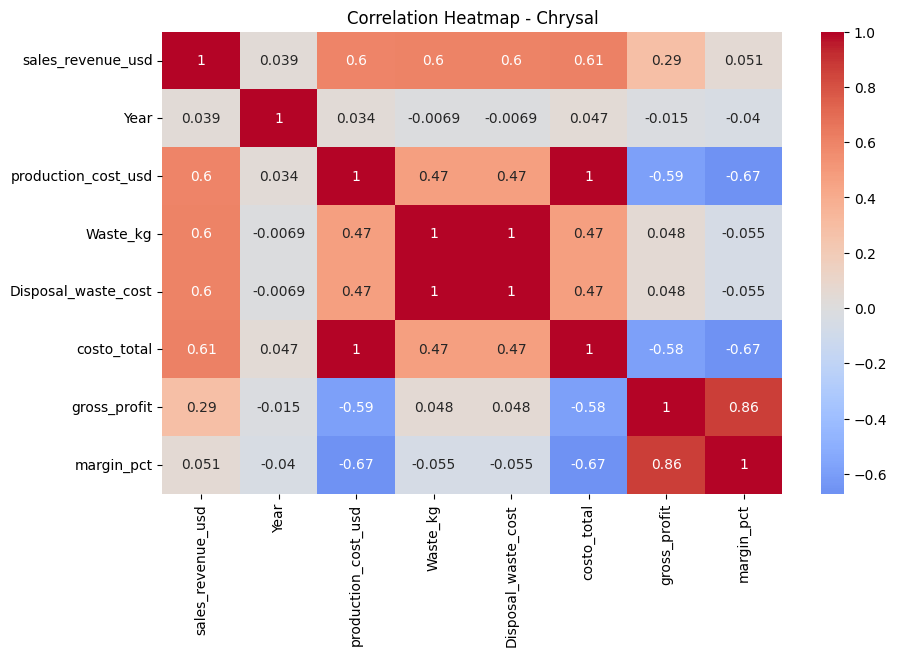

In [ ]:
numeric_sales_final = sales_final.select_dtypes(include=np.number)
corr_matrix = numeric_sales_final.corr()
plt.figure(figsize=(10, 6))
sns.heatmap(corr_matrix, annot=True, cmap="coolwarm", center=0)
plt.title("Correlation Heatmap - Chrysal")
plt.show()

**🎯CONCLUSIONES:**
- En este analisis hay varias variables calculadas entre si como "costo_total" y "sales_revenue_usd" para calcular "gross_profit" y "margin_pct" por tal razon hay relacion entre variables porque son provenientes de calculos entre ellas mismas.
- Es importante mencionar que las ventas "sales_revenue_usd" y "production_costs" tienen una relacion fuerte positiva con un coeficiente de correlacion de 0.92
-  Se evidencia que production .

Pendiente: analisis de outliers y calculo de ROI haciendo merge de marketing